# 0. Load

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
df_org = pd.read_excel("../Data/churn_prediction.xlsx")
df_org.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Mobile Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


# 1. Inspecting

## a. Describe

In [3]:
Dtype = []
Distinct = []
Unique = []
Na_count = []
Na_pct = []
for col in df_org.columns:
    dt = str(df_org[col].dtypes)
    dis = df_org[col].nunique()
    un = df_org[col].value_counts().eq(1).sum()
    na_c = df_org[col].isna().sum()
    na_p = na_c*100/len(df_org)

    Dtype.append(dt)
    Distinct.append(dis)
    Unique.append(un)
    Na_count.append(na_c)
    Na_pct.append(na_p.round(2))
info = pd.DataFrame({
    "Columns": list(df_org.columns),
    "Dtype": Dtype,
    "Distinct": Distinct,
    "Unique": Unique,
    "NA Count": Na_count,
    "NA Pct": Na_pct
})
print(f"Memory usage: {df_org.memory_usage().sum()/1024**2:.2f} MB")
print(f"{df_org.shape[0]:,.0f} rows x {df_org.shape[1]:,.0f} cols")
print(info.set_index("Columns").sort_values("NA Pct"))

Memory usage: 1.08 MB
5,630 rows x 20 cols
                               Dtype  Distinct  Unique  NA Count  NA Pct
Columns                                                                 
CustomerID                     int64      5630    5630         0    0.00
Complain                       int64         2       0         0    0.00
NumberOfAddress                int64        15       4         0    0.00
MaritalStatus                    str         3       0         0    0.00
SatisfactionScore              int64         5       0         0    0.00
PreferedOrderCat                 str         6       0         0    0.00
Gender                           str         2       0         0    0.00
NumberOfDeviceRegistered       int64         6       0         0    0.00
CityTier                       int64         3       0         0    0.00
PreferredLoginDevice             str         3       0         0    0.00
Churn                          int64         2       0         0    0.00
Preferre

## b. Features values summary

In [4]:
print(df_org.describe().T.round(4).drop(columns = "count"))

                                   mean        std      min       25%  \
CustomerID                   52815.5000  1625.3853  50001.0  51408.25   
Churn                            0.1684     0.3742      0.0      0.00   
Tenure                          10.1899     8.5572      0.0      2.00   
CityTier                         1.6547     0.9154      1.0      1.00   
WarehouseToHome                 15.6399     8.5315      5.0      9.00   
HourSpendOnApp                   2.9315     0.7219      0.0      2.00   
NumberOfDeviceRegistered         3.6890     1.0240      1.0      3.00   
SatisfactionScore                3.0668     1.3802      1.0      2.00   
NumberOfAddress                  4.2140     2.5836      1.0      2.00   
Complain                         0.2849     0.4514      0.0      0.00   
OrderAmountHikeFromlastYear     15.7079     3.6755     11.0     13.00   
CouponUsed                       1.7510     1.8946      0.0      1.00   
OrderCount                       3.0080     2.9397 

In [5]:
str_col = df_org.select_dtypes(exclude = "number").columns
for col in str_col:
    print(f"\n{col}: {df_org[col].nunique()}")
    print(df_org[col].unique().tolist())


PreferredLoginDevice: 3
['Mobile Phone', 'Computer', 'Phone']

PreferredPaymentMode: 7
['E wallet', 'Cash on Delivery', 'Debit Card', 'UPI', 'Credit Card', 'COD', 'CC']

Gender: 2
['Female', 'Male']

PreferedOrderCat: 6
['Fashion', 'Laptop & Accessory', 'Mobile Phone', 'Grocery', 'Mobile', 'Others']

MaritalStatus: 3
['Married', 'Single', 'Divorced']


## c. NA & Duplicated values

NA rows: 1856
NA pct: 32.97%


<Axes: >

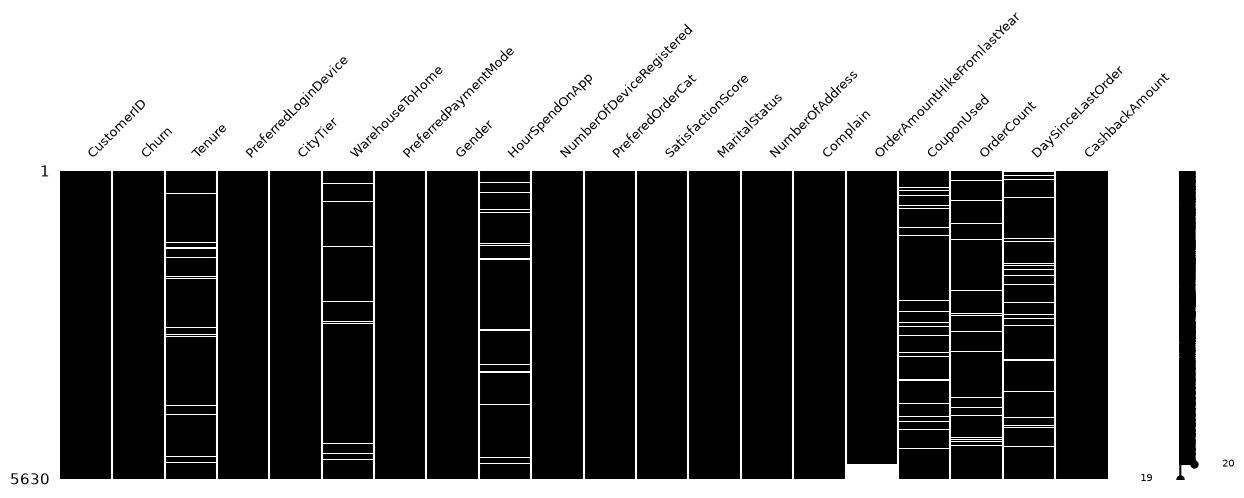

In [6]:
print(f"NA rows: {df_org.isna().any(axis = 1).sum()}")
print(f"NA pct: {df_org.isna().any(axis = 1).sum()/len(df_org):.2%}")
msno.matrix(df_org, figsize = (15,4), fontsize = 9, color = (0, 0, 0))

<Axes: >

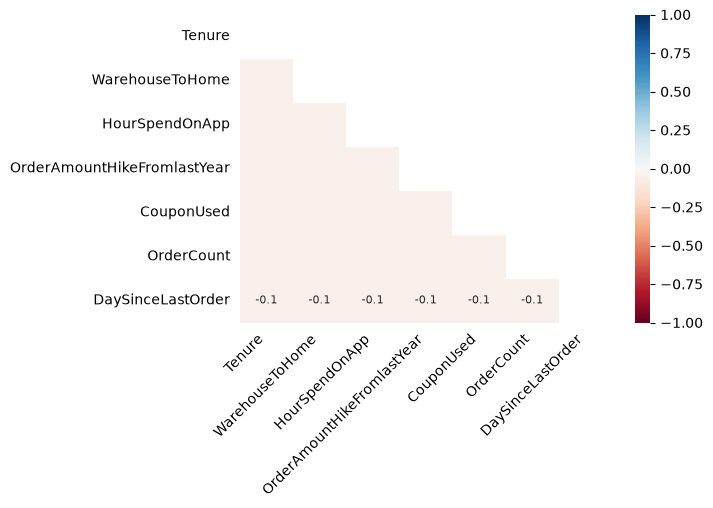

In [7]:
msno.heatmap(df_org, figsize = (6,4), fontsize = 10)

In [8]:
print(f"Dup count: {df_org.duplicated().sum()}")
print(f"Dup pct: {df_org.duplicated().sum()/len(df_org):.2%}")

Dup count: 0
Dup pct: 0.00%


# 2. Cleaning data

In [33]:
df = df_org.copy()

## a. Replace values

In [34]:
for col in str_col:
    print(f"\n{col}: {df_org[col].nunique()}")
    print(df_org[col].unique().tolist())


PreferredLoginDevice: 3
['Mobile Phone', 'Computer', 'Phone']

PreferredPaymentMode: 7
['E wallet', 'Cash on Delivery', 'Debit Card', 'UPI', 'Credit Card', 'COD', 'CC']

Gender: 2
['Female', 'Male']

PreferedOrderCat: 6
['Fashion', 'Laptop & Accessory', 'Mobile Phone', 'Grocery', 'Mobile', 'Others']

MaritalStatus: 3
['Married', 'Single', 'Divorced']


In [35]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({"Mobile Phone": "Phone"})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'Cash on Delivery': 'COD', 'Credit Card': 'CC'})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile Phone': 'Phone', 'Mobile': 'Phone'})
str_col = df.select_dtypes(exclude = "number").columns
for col in str_col:
    print(f"\n{col}: {df[col].nunique()}")
    print(df[col].unique().tolist())


PreferredLoginDevice: 2
['Phone', 'Computer']

PreferredPaymentMode: 5
['E wallet', 'COD', 'Debit Card', 'UPI', 'CC']

Gender: 2
['Female', 'Male']

PreferedOrderCat: 5
['Fashion', 'Laptop & Accessory', 'Phone', 'Grocery', 'Others']

MaritalStatus: 3
['Married', 'Single', 'Divorced']


## b. Missing values

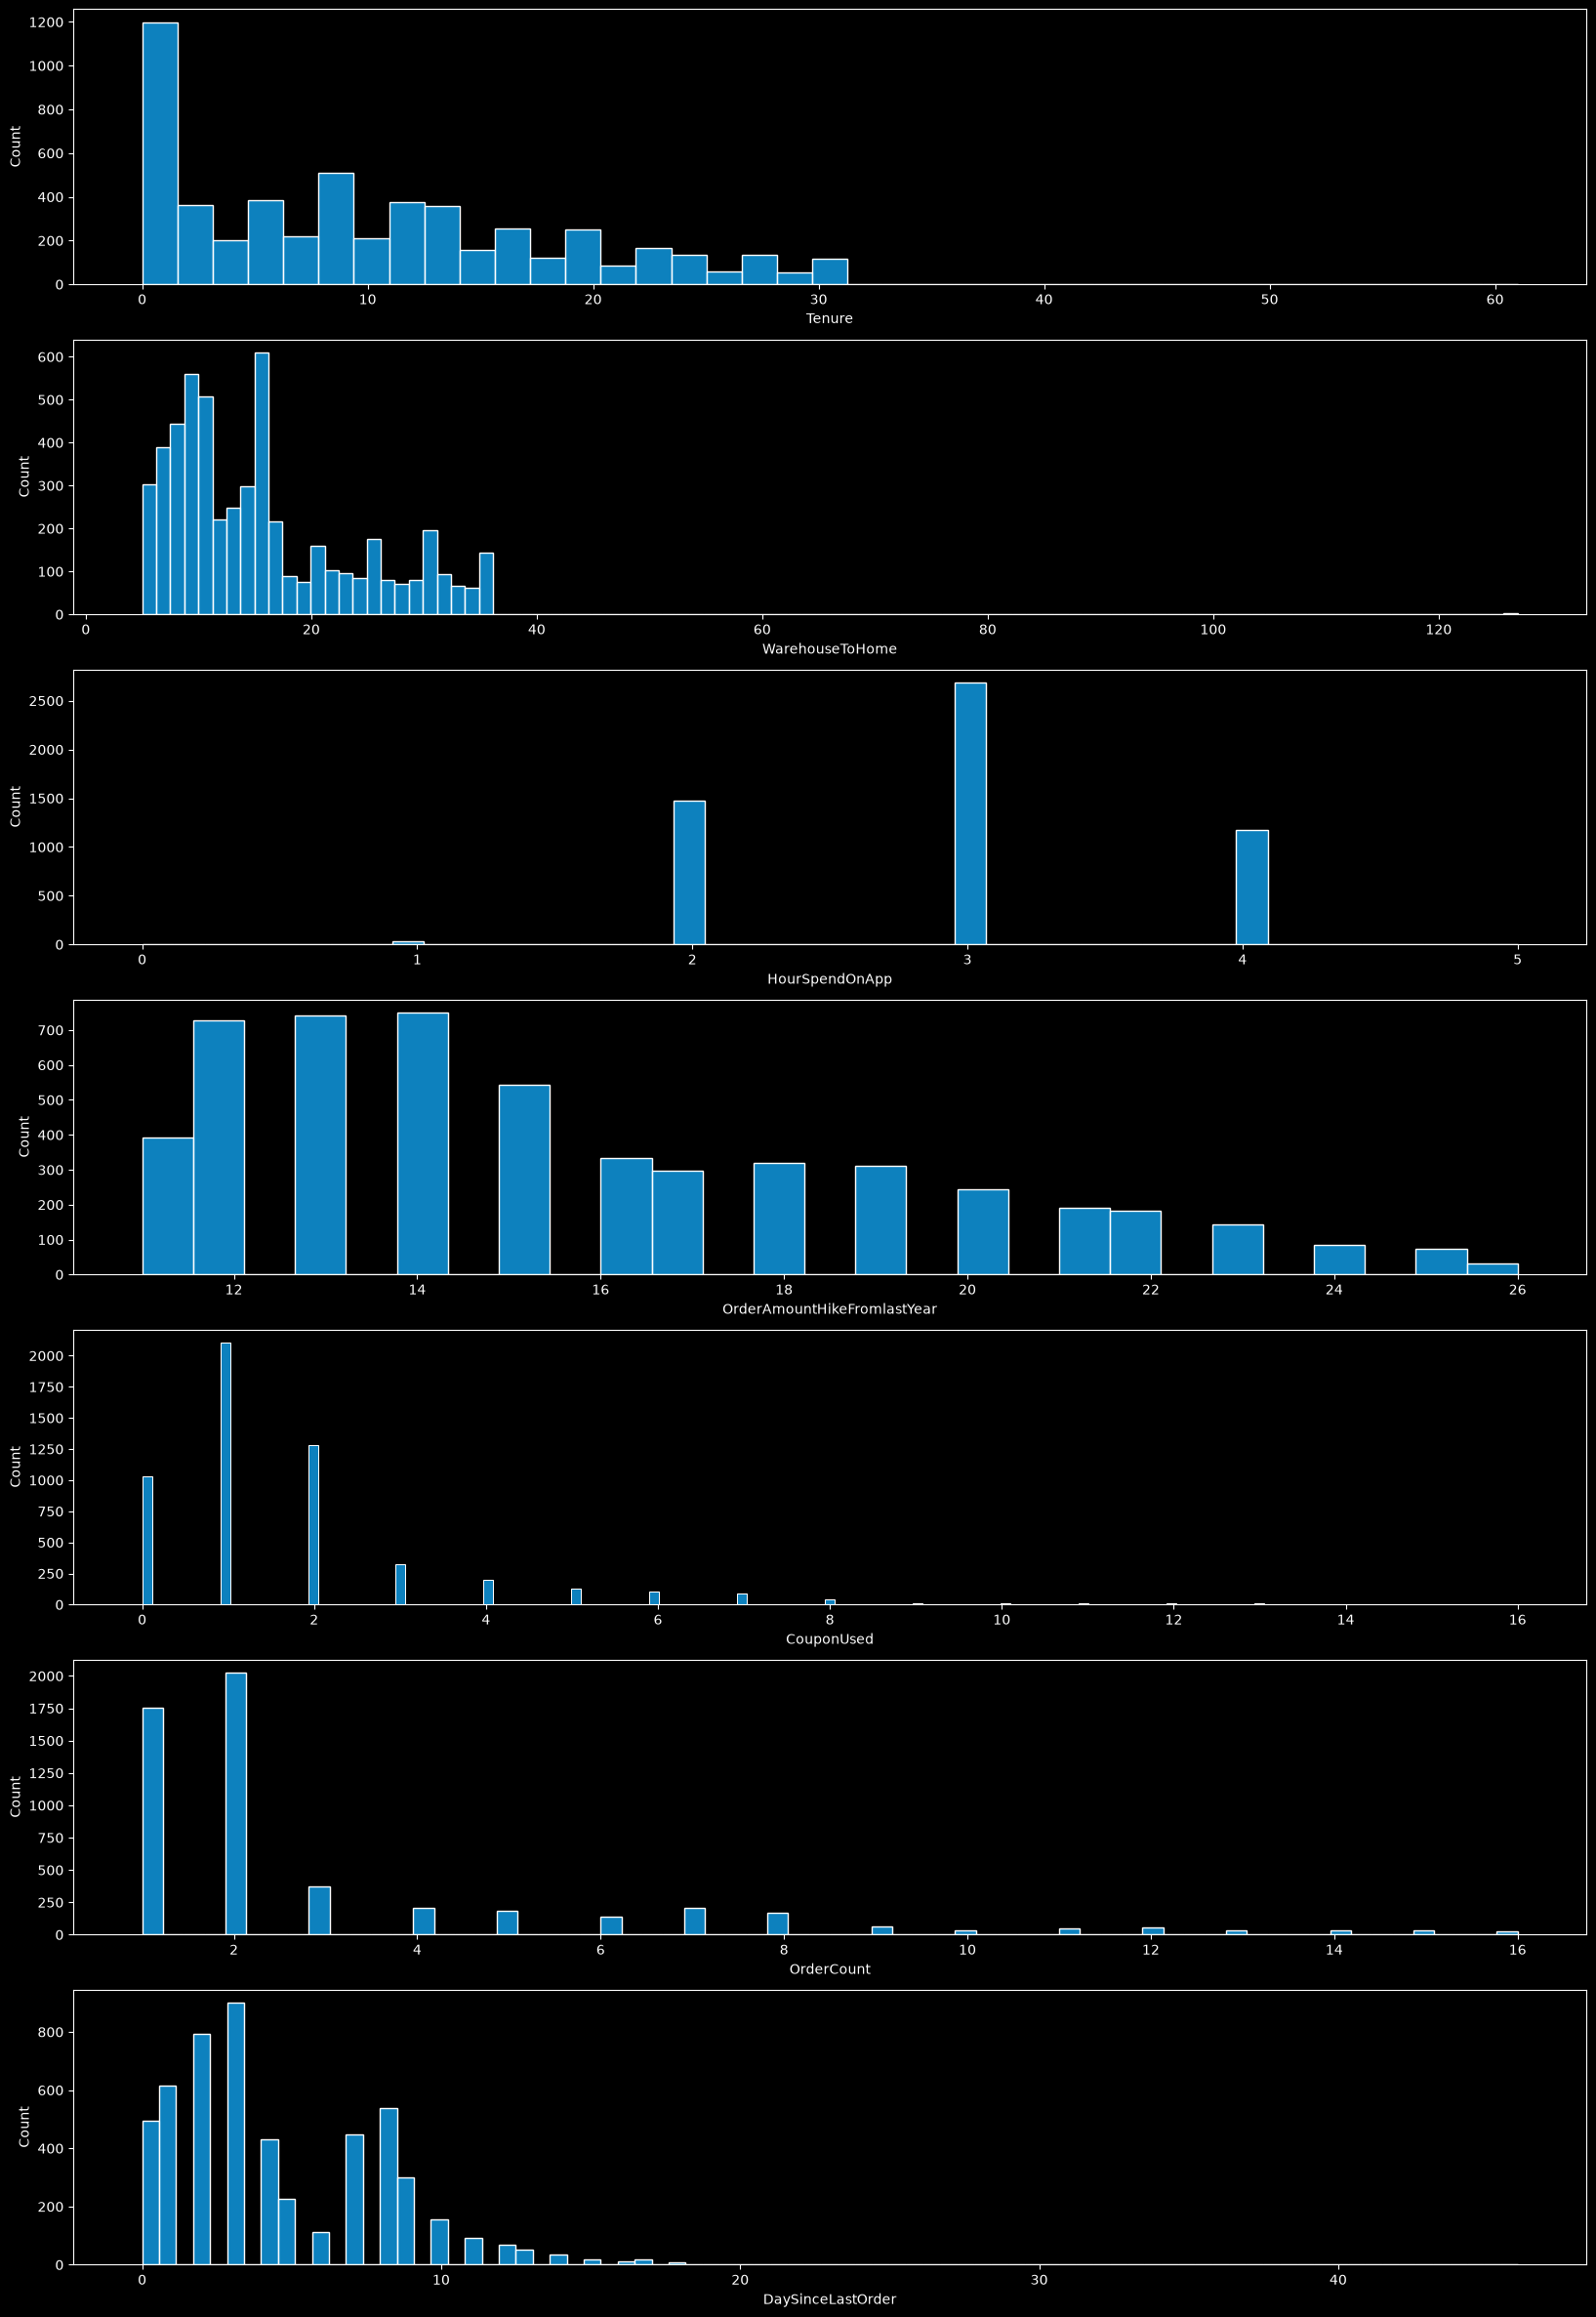

In [36]:
na_col = df.columns[df.isna().any()].tolist()
plt.style.use('dark_background')
fig, ax = plt.subplots(nrows = len(na_col), ncols = 1, figsize = (20, 30))
for i in range(len(na_col)):
    sns.histplot(data = df, x = na_col[i], ax = ax[i], color = "#12aeff")

plt.show()

In [37]:
for col in na_col:
    med = df[col].median()
    df[col] = df[col].fillna(med)

In [38]:
Dtype = []
Distinct = []
Unique = []
Na_count = []
Na_pct = []
for col in df.columns:
    dt = str(df[col].dtypes)
    dis = df[col].nunique()
    un = df[col].value_counts().eq(1).sum()
    na_c = df[col].isna().sum()
    na_p = na_c*100/len(df)

    Dtype.append(dt)
    Distinct.append(dis)
    Unique.append(un)
    Na_count.append(na_c)
    Na_pct.append(na_p.round(2))
info = pd.DataFrame({
    "Columns": list(df.columns),
    "Dtype": Dtype,
    "Distinct": Distinct,
    "Unique": Unique,
    "NA Count": Na_count,
    "NA Pct": Na_pct
})
print(f"Memory usage: {df.memory_usage().sum()/1024**2:.2f} MB")
print(f"{df.shape[0]:,.0f} rows x {df.shape[1]:,.0f} cols")
print(info.set_index("Columns").sort_values("NA Pct"))

Memory usage: 1.04 MB
5,630 rows x 20 cols
                               Dtype  Distinct  Unique  NA Count  NA Pct
Columns                                                                 
CustomerID                     int64      5630    5630         0     0.0
OrderCount                   float64        16       0         0     0.0
CouponUsed                   float64        17       1         0     0.0
OrderAmountHikeFromlastYear  float64        16       0         0     0.0
Complain                       int64         2       0         0     0.0
NumberOfAddress                int64        15       4         0     0.0
MaritalStatus                    str         3       0         0     0.0
SatisfactionScore              int64         5       0         0     0.0
PreferedOrderCat                 str         5       0         0     0.0
NumberOfDeviceRegistered       int64         6       0         0     0.0
HourSpendOnApp               float64         6       0         0     0.0
Gender  

# 3. Extract

In [39]:
df.to_csv("../Data/churn_processed.csv", index = False)